In [2]:
import numpy as np 
import h5py
from pathlib import Path 
import IPython.display as ipd 
import pickle 
%matplotlib inline 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import copy



In [18]:
model = "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout"

analysis_dir = Path(f"binaural_unit_activations/{model}")

anova_results = list(analysis_dir.glob("*.npz"))

model = "word_task_half_co_loc_v08_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout"

analysis_dir = Path(f"binaural_unit_activations/{model}")

h5_fn = analysis_dir / f"{model}_model_activations_0dB_time_avg.h5"

h5 = h5py.File(h5_fn, "r") 

target_f0s = h5["target_f0"][:]
target_locs = h5["target_loc"][:]
# h5.close()

48
12
Optimal number of bins: 9


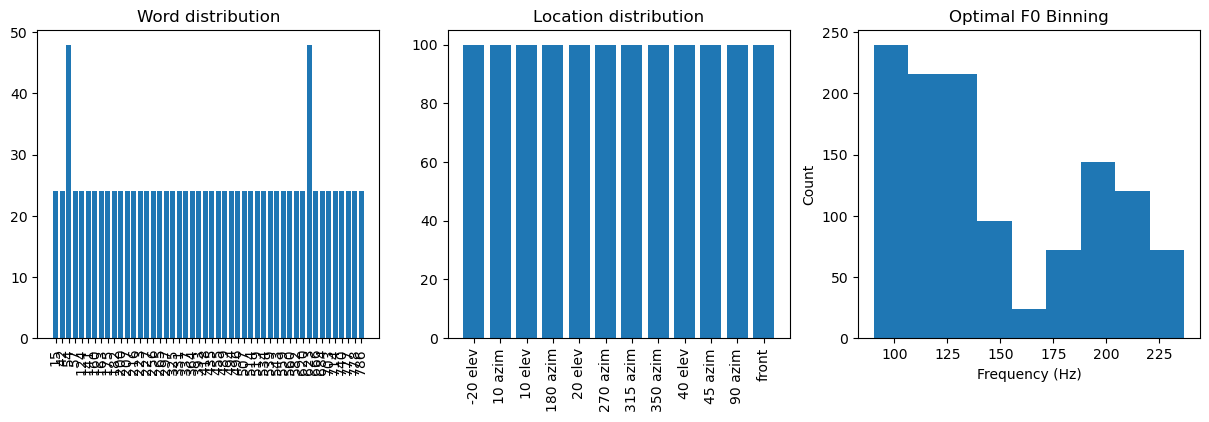

In [62]:
plt.figure(figsize=(15, 4))
plt.subplot(131)
words, count = np.unique(h5['target_word_int'][:], return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(words))
plt.xticks(np.arange(len(count)), words.astype('int'), rotation=90);
plt.title('Word distribution')

### get binning for location classes 

#  
unique_locations = np.unique(target_locs, axis=0).astype(int)
# print(unique_locations)
loc_list = np.zeros(len(target_locs), dtype=object)
for loc in unique_locations:
    loc_ixs = np.where(np.all(target_locs == loc, axis=1))[0]
    azim, elev = loc
    if elev == 0 and azim == 0:
        loc_list[loc_ixs] = 'front'
    elif elev == 0:
        loc_list[loc_ixs] = f"{azim} azim"
    elif azim == 0:
        loc_list[loc_ixs] = f"{elev} elev"

plt.subplot(132)
locs, count = np.unique(loc_list, return_counts=True)
plt.bar(np.arange(len(count)), count)
print(len(locs))
plt.xticks(np.arange(len(locs)), locs, rotation=90);
plt.title('Location distribution')


### get binning for pitch classes 
def optimal_bin_count(data, min_bins=1, max_bins=50):
    # Calculate the Freedman-Diaconis bin width
    q25, q75 = np.percentile(data, [25, 75])
    bin_width = 2 * (q75 - q25) * len(data) ** (-1/3)
    bin_width = max(bin_width, 1e-5)  # Ensure bin width is not zero

    # Calculate the range of bin counts to test
    data_range = np.ptp(data)
    min_bins = max(min_bins, int(np.ceil(data_range / bin_width)))
    max_bins = min(max_bins, int(np.floor(data_range / bin_width)))

    best_bin_count = min_bins
    best_variance = float('inf')

    # Iterate over the range of bin counts
    for bins in range(min_bins, max_bins + 1):
        counts, _ = np.histogram(data, bins=bins)
        variance = np.var(counts)
        if variance < best_variance:
            best_variance = variance
            best_bin_count = bins

    return best_bin_count

plt.subplot(133)
# Example usage with target_f0s data
# target_f0s = np.random.rand(100) * 100  # Replace with your actual data
optimal_bins = optimal_bin_count(target_f0s)
print(f"Optimal number of bins: {optimal_bins}")

# Plot the histogram with the optimal number of bins
plt.hist(target_f0s, bins=optimal_bins)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
plt.title('Optimal F0 Binning')
plt.show()




In [63]:
results_dict = {}

for result in anova_results:
    layer_name = "_".join(result.stem.split("_")[:3])
    print(layer_name)
    results = np.load(result)
    results_dict[layer_name] = {"prop_var_exp": results['prop_var_per_unit'], 'ssq_per_unit':results['ssq_per_unit']}

category_labels = results['category_labels']

hann_pool_0
hann_pool_1
hann_pool_2
hann_pool_6


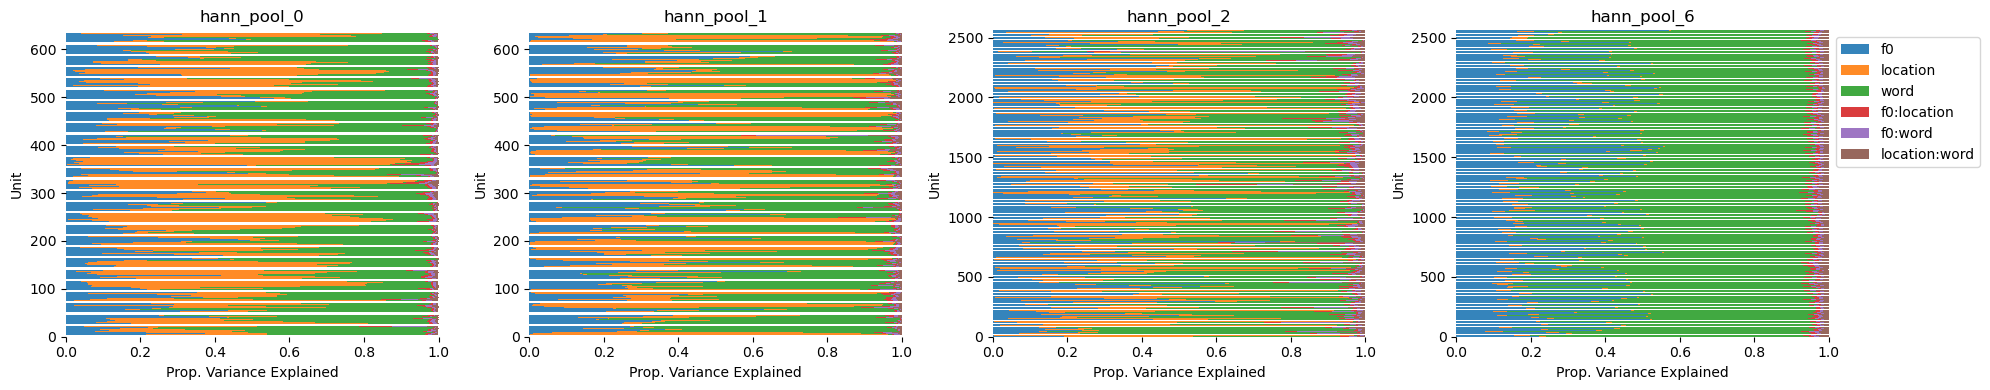

In [35]:
n_to_plot = len(results_dict)

fig, ax = plt.subplots(1, n_to_plot, figsize=(20, 4))

n_cats = len(category_labels) # will be for location, f0, interaction

for layer_ix, (layer_name, results) in enumerate(results_dict.items()):
    results_to_plot_prop = results['prop_var_exp']
    n_units = results_to_plot_prop.shape[0]
    bottom = np.zeros(n_units)

    for cat_ix in range(n_cats):
        # sns.barplot(x=np.arange(n_units), y=results_to_plot_prop[:, cat_ix],  color=f"C{cat_ix}", ax=ax[layer_ix], orient='h', label=category_labels[cat_ix])
        ax[layer_ix].barh(np.arange(n_units), results_to_plot_prop[:, cat_ix],  color=f"C{cat_ix}", label=category_labels[cat_ix], alpha=0.9, left=bottom)
        bottom += results_to_plot_prop[:, cat_ix]
        
    ax[layer_ix].set_xlabel('Prop. Variance Explained')
    ax[layer_ix].set_ylabel('Unit')
    ax[layer_ix].set_title(layer_name)
    ax[layer_ix].set_ylim(0, n_units)
    ax[layer_ix].set_xlim(0, 1)

    if layer_ix < n_to_plot-1:
        # remove legend for all but last plot
        ax[layer_ix].legend().set_visible(False)
    else:
        ax[layer_ix].legend(loc='upper left', bbox_to_anchor=(1, 1))

    # move legend outside of plot
sns.despine(left=True, bottom=True)

plt.tight_layout()



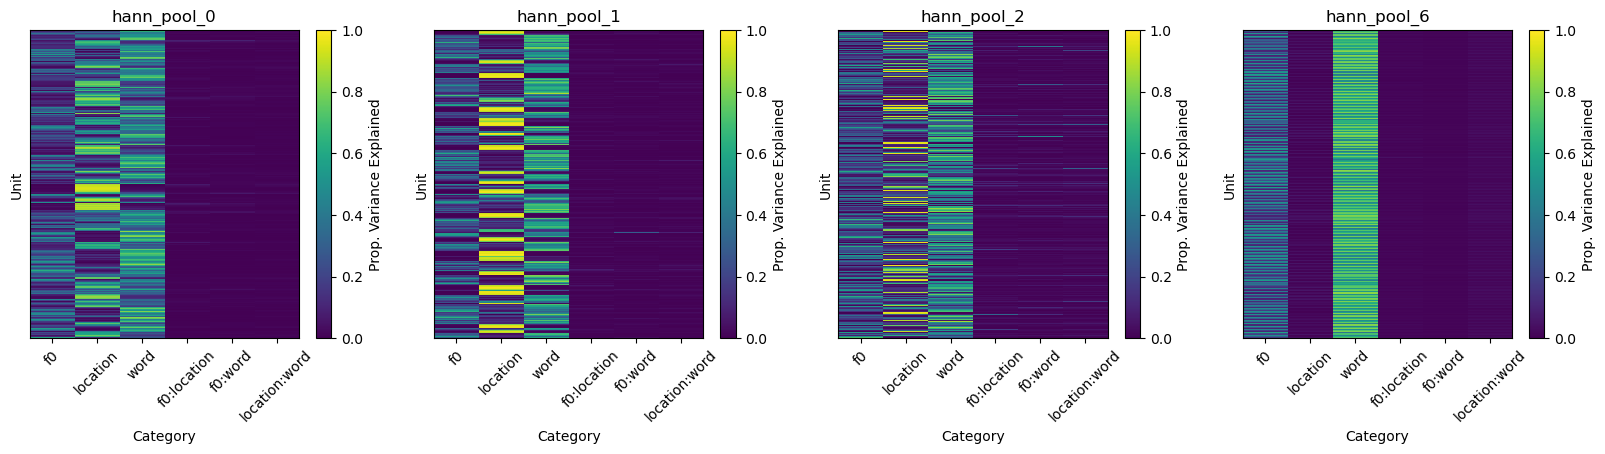

In [64]:
### Use imshow to plot the SSQ per unit
n_to_plot = len(results_dict)
fig, ax = plt.subplots(1, n_to_plot, figsize=(20, 4))

n_cats = len(category_labels) # will be for location, f0, interaction
for layer_ix, (layer_name, results) in enumerate(results_dict.items()):
    results_to_plot_ssq = results['prop_var_exp']
    n_units = results_to_plot_ssq.shape[0]
    panel = ax[layer_ix].imshow(results_to_plot_ssq, aspect='auto', cmap='viridis', vmin=0, vmax=1, interpolation='none')
    ax[layer_ix].set_xlabel('Category')
    ax[layer_ix].set_ylabel('Unit')
    ax[layer_ix].set_title(layer_name)
    ax[layer_ix].set_yticks([])
    ax[layer_ix].set_xticks(np.arange(n_cats))
    ax[layer_ix].set_xticklabels(category_labels, rotation=45)
    # add colorbar
    cbar = plt.colorbar(panel, ax=ax[layer_ix])
    cbar.set_label('Prop. Variance Explained')
    


    # move legend outside of plot